# WellMind AI - 2. Model Training & Comparison

Loads the processed train/test data from notebook 1, trains a few simple
classifiers, compares them, and saves the best one.

In [ ]:
# Install XGBoost if it's not already available
!pip install xgboost --quiet


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

RANDOM_STATE = 42


## 1. Load the Processed Data

In [21]:
train_df = pd.read_csv("data/train_processed.csv")
test_df = pd.read_csv("data/test_processed.csv")
y_test = pd.read_csv("test_targets.csv")["Lifestyle Category"]

feature_cols = joblib.load("feature_cols.pkl")

X_train = train_df[feature_cols]
y_train = train_df["Lifestyle Category"]
X_test = test_df[feature_cols]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (12000, 10)
Test shape: (3000, 10)


## 2. Encode the Target Labels

In [22]:
target_encoder = LabelEncoder()
y_train_enc = target_encoder.fit_transform(y_train)
y_test_enc = target_encoder.transform(y_test)

print("Classes:", list(target_encoder.classes_))


Classes: ['Average', 'Healthy', 'Poor']


## 3. Train a Few Models & Compare Them

In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
    ),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train_enc)

    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train_enc, y_train_pred)
    acc = accuracy_score(y_test_enc, y_pred)
    f1 = f1_score(y_test_enc, y_pred, average="macro")

    results.append({
        "Model": name,
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(acc, 4),
        "Gap (Train-Test)": round(train_acc - acc, 4),
        "Macro F1": round(f1, 4),
    })
    fitted_models[name] = model
    print(f"{name}: Train Acc={train_acc:.4f}, Test Acc={acc:.4f}, Macro F1={f1:.4f}")

comparison = pd.DataFrame(results).sort_values("Macro F1", ascending=False)
comparison.to_csv("model_comparison.csv", index=False)
comparison


Logistic Regression: Train Acc=0.7957, Test Acc=0.7800, Macro F1=0.7638
Decision Tree: Train Acc=0.8265, Test Acc=0.7740, Macro F1=0.7537
Random Forest: Train Acc=0.8483, Test Acc=0.7877, Macro F1=0.7641
K-Nearest Neighbors: Train Acc=0.8518, Test Acc=0.8307, Macro F1=0.7875
XGBoost: Train Acc=0.8696, Test Acc=0.8393, Macro F1=0.7925


,Model,Train Accuracy,Test Accuracy,Gap (Train-Test),Macro F1
4,XGBoost,0.8696,0.8393,0.0302,0.7925
3,K-Nearest Neighbors,0.8518,0.8307,0.0211,0.7875
2,Random Forest,0.8483,0.7877,0.0607,0.7641
0,Logistic Regression,0.7957,0.7800,0.0157,0.7638
1,Decision Tree,0.8265,0.7740,0.0525,0.7537


## 3b. Overfitting Check

If **Train Accuracy** is much higher than **Test Accuracy** (a big gap, e.g. more
than ~5-8 points), the model is memorizing the training data instead of learning
general patterns - that's overfitting.

Note: because `Lifestyle Category` was built from a formula on these same lifestyle
features (with a bit of random noise added), it's normal to see *both* train and
test accuracy quite high here. The important check is the **gap** between them,
not the absolute accuracy number.

                 Model  Train Accuracy  Test Accuracy  Gap (Train-Test)
4              XGBoost          0.8696         0.8393            0.0302
3  K-Nearest Neighbors          0.8518         0.8307            0.0211
2        Random Forest          0.8483         0.7877            0.0607
0  Logistic Regression          0.7957         0.7800            0.0157
1        Decision Tree          0.8265         0.7740            0.0525


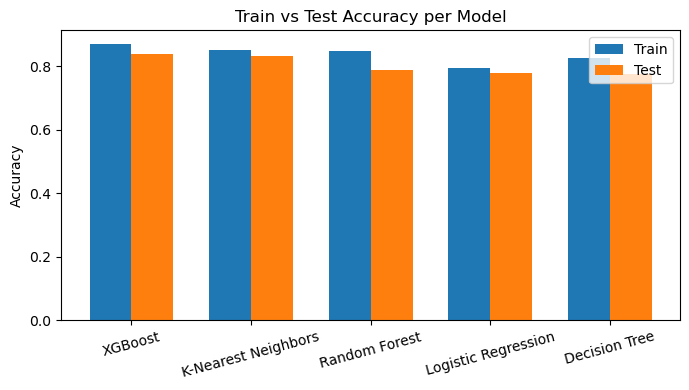

XGBoost: gap=0.0302 -> looks OK
K-Nearest Neighbors: gap=0.0211 -> looks OK
Random Forest: gap=0.0607 -> looks OK
Logistic Regression: gap=0.0157 -> looks OK
Decision Tree: gap=0.0525 -> looks OK


In [24]:
print(comparison[["Model", "Train Accuracy", "Test Accuracy", "Gap (Train-Test)"]])

plt.figure(figsize=(7, 4))
x = np.arange(len(comparison))
width = 0.35
plt.bar(x - width/2, comparison["Train Accuracy"], width, label="Train")
plt.bar(x + width/2, comparison["Test Accuracy"], width, label="Test")
plt.xticks(x, comparison["Model"], rotation=15)
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy per Model")
plt.legend()
plt.tight_layout()
plt.show()

for _, row in comparison.iterrows():
    gap = row["Gap (Train-Test)"]
    flag = "OVERFITTING RISK" if gap > 0.08 else "looks OK"
    print(f"{row['Model']}: gap={gap:.4f} -> {flag}")


## 4. Look Closer at the Best Model

Best model: XGBoost
              precision    recall  f1-score   support

     Average       0.85      0.88      0.87      1784
     Healthy       0.80      0.56      0.66       395
        Poor       0.82      0.88      0.85       821

    accuracy                           0.84      3000
   macro avg       0.83      0.77      0.79      3000
weighted avg       0.84      0.84      0.84      3000



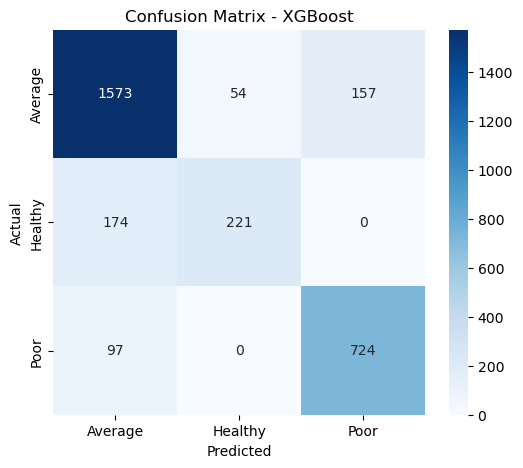

In [16]:
best_name = comparison.iloc[0]["Model"]
best_model = fitted_models[best_name]
y_best_pred = best_model.predict(X_test)

print("Best model:", best_name)
print(classification_report(y_test_enc, y_best_pred, target_names=target_encoder.classes_))

cm = confusion_matrix(y_test_enc, y_best_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()


## 4b. Hyperparameter Tuning

Instead of using the default settings, we search over a few reasonable
hyperparameter combinations for the best model and pick the ones that work
best, using 5-fold cross-validation on the training data. This uses
`RandomizedSearchCV`, which is faster than trying every single combination.

In [17]:
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["lbfgs"],
    },
    "Decision Tree": {
        "max_depth": [4, 6, 8, 12, 16, None],
        "min_samples_leaf": [1, 2, 5, 10],
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [6, 10, 15, None],
        "min_samples_leaf": [1, 2, 5],
    },
    "Gradient Boosting": {
        "n_estimators": [100, 200, 300],
        "max_depth": [2, 3, 4],
        "learning_rate": [0.03, 0.1, 0.2],
    },
    "K-Nearest Neighbors": {
        "n_neighbors": [5, 10, 15, 25],
        "weights": ["uniform", "distance"],
    },
    "XGBoost": {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.03, 0.1, 0.2],
    },
}

base_model = models[best_name]
grid = param_grids[best_name]

search = RandomizedSearchCV(
    base_model,
    param_distributions=grid,
    n_iter=10,
    scoring="f1_macro",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
search.fit(X_train, y_train_enc)

print("Best parameters found:", search.best_params_)
print("Best cross-validation Macro F1:", round(search.best_score_, 4))

tuned_model = search.best_estimator_
y_tuned_pred = tuned_model.predict(X_test)

tuned_acc = accuracy_score(y_test_enc, y_tuned_pred)
tuned_f1 = f1_score(y_test_enc, y_tuned_pred, average="macro")

print(f"\nBefore tuning -> Test Accuracy={comparison.iloc[0]['Test Accuracy']:.4f}, Macro F1={comparison.iloc[0]['Macro F1']:.4f}")
print(f"After tuning  -> Test Accuracy={tuned_acc:.4f}, Macro F1={tuned_f1:.4f}")

# Keep whichever version (tuned or original) scores better on the test set
if tuned_f1 >= comparison.iloc[0]["Macro F1"]:
    best_model = tuned_model
    print("\nUsing the TUNED model going forward.")
else:
    best_model = fitted_models[best_name]
    print("\nTuning did not improve results, keeping the ORIGINAL model.")


Best parameters found: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Best cross-validation Macro F1: 0.8083

Before tuning -> Test Accuracy=0.8393, Macro F1=0.7925
After tuning  -> Test Accuracy=0.8447, Macro F1=0.7996

Using the TUNED model going forward.


## 5. Feature Importance

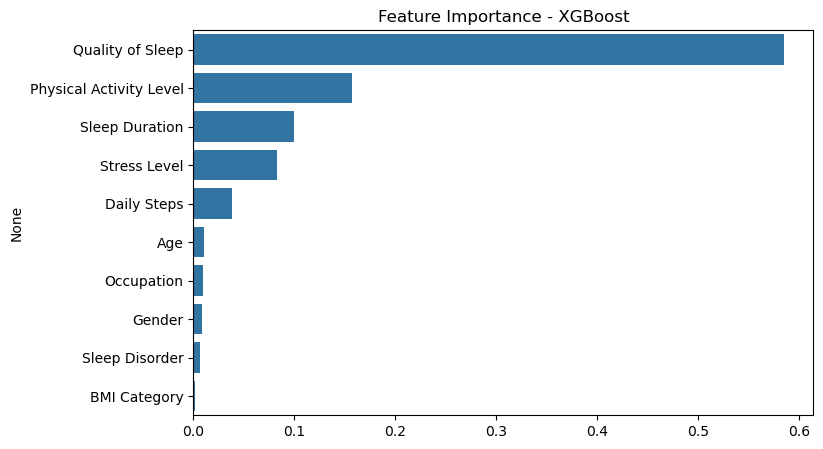

In [18]:
if hasattr(best_model, "feature_importances_"):
    importance = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=importance.values, y=importance.index)
    plt.title(f"Feature Importance - {best_name}")
    plt.show()
else:
    print(f"{best_name} does not expose feature importances.")


## 6. Save the Best Model

In [19]:
joblib.dump(best_model, "data/best_model.pkl")
joblib.dump(target_encoder, "data/target_encoder.pkl")

print(f"Saved best_model.pkl ({best_name}) and target_encoder.pkl")


Saved best_model.pkl (XGBoost) and target_encoder.pkl
